# 6. Explainable AI (XAI) & Biomarker Discovery

**Goal:** In Notebook `05b`, we finalized 8 predictive models across two classification tasks (UC vs nonIBD and CD vs nonIBD) using two feature selectors (Kruskal-Wallis and PCA) and two algorithms (Logistic Regression and SVM). 

While accuracy is critical, clinical data science requires **interpretability**. In this notebook, we open the "black boxes" of our models to identify which specific bacteria are driving the predictions.

**Methodology:**
1. **Logistic Regression (Linear Explanations):** We extract the direct mathematical weights (coefficients). For PCA-based models, we apply an inverse-transformation (`np.dot(coefficients, pca_components)`) to project the weights back to the original 2,761 raw microbes.
2. **Support Vector Machines (Non-Linear Explanations):** We utilize Game Theory via **SHAP (SHapley Additive exPlanations)**. We compute SHAP values using `KernelExplainer`. For PCA-SVM models, we apply the same inverse-transformation trick to the SHAP values to reveal the raw bacterial drivers of the non-linear decision boundary.

In [17]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import warnings
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import kruskal

warnings.filterwarnings("ignore")
os.makedirs('../results/figures', exist_ok=True)

print("XAI Libraries loaded.")

XAI Libraries loaded.


### 2. Custom Class Definition & Data Loading
To properly load the `.pkl` models generated in the previous notebook, we must redefine the `KruskalSelector` class here so `joblib` recognizes the custom pipeline step.

In [18]:
# 2. Data and Class Setup

# Redefine Custom Selector to allow joblib to unpickle the models
class KruskalSelector(BaseEstimator, TransformerMixin):
    def __init__(self, p_threshold=0.01):
        self.p_threshold = p_threshold
        self.selected_features_ = None
        
    def fit(self, X, y):
        pass # Not needed for loading/transforming
        
    def transform(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return X_arr[:, self.selected_indices_]
    
    def get_feature_names_out(self):
        return self.selected_features_

# Load data
meta = pd.read_csv("../data/processed/metadata_final.tsv", sep="\t", index_col="Sample")
genera_clr = pd.read_csv("../data/processed/genera_clr.tsv", sep="\t", index_col=0)
meta = meta.loc[genera_clr.index]

def make_binary_dataset(meta, genera, group_a, group_b):
    mask = meta["Study.Group"].isin([group_a, group_b])
    meta_sub = meta[mask]
    X = genera.loc[meta_sub.index]
    y = (meta_sub["Study.Group"] == group_a).astype(int)
    return X, y

X_uc, y_uc = make_binary_dataset(meta, genera_clr, "UC", "nonIBD")
X_cd, y_cd = make_binary_dataset(meta, genera_clr, "CD", "nonIBD")

print(f"Datasets ready. UC: {X_uc.shape[0]} | CD: {X_cd.shape[0]}")

Datasets ready. UC: 56 | CD: 75


### 3. Logistic Regression Explainability (Coefficients)
Logistic Regression provides built-in interpretability. 
* **KW Pipelines:** The coefficients map directly to the selected microbes.
* **PCA Pipelines:** The model assigns coefficients to the Principal Components. We multiply these PC coefficients by the PCA loading matrix to calculate the effective weight of every raw microbe.

In [19]:
# 3. Extracting and Plotting Logistic Regression Coefficients

def extract_logreg_coefs(pipeline, X_raw, selector_type):
    """Extracts raw feature coefficients, handling the Inverse-PCA trick if needed."""
    clf = pipeline.named_steps['clf']
    
    if selector_type == "KW":
        feat_sel = pipeline.named_steps['feat_sel']
        features = feat_sel.get_feature_names_out()
        coefs = clf.coef_[0]
        return pd.Series(coefs, index=features)
        
    elif selector_type == "PCA":
        pca = pipeline.named_steps['feat_sel']
        pca_coefs = clf.coef_[0]
        # Inverse PCA Trick for Coefficients
        raw_coefs = np.dot(pca_coefs, pca.components_)
        return pd.Series(raw_coefs, index=X_raw.columns)

def plot_logreg_importance(coef_series, title, file_name):
    """Plots the top 20 most impactful features by absolute weight."""
    # Clean names: keep only the final genus
    clean_series = coef_series.copy()
    clean_series.index = [g.split(";")[-1].strip() for g in clean_series.index]
    
    # Get top 20 by absolute magnitude
    top_20 = clean_series.reindex(clean_series.abs().sort_values(ascending=False).index[:20])
    
    plt.figure(figsize=(10, 6))
    colors = ['#d65f5f' if c > 0 else '#5f8cd6' for c in top_20.values]
    
    sns.barplot(x=top_20.values, y=top_20.index, palette=colors)
    plt.title(f"{title}\nTop 20 Features (LogReg Coefficients)", fontsize=13, fontweight='bold')
    plt.xlabel("Coefficient Weight (Red = Predicts Disease, Blue = Predicts nonIBD)")
    plt.tight_layout()
    plt.savefig(f"../results/figures/{file_name}", dpi=150)
    plt.close()
    print(f"Saved: {file_name}")

print("=== Logistic Regression Interpretability ===")
logreg_models = {
    "UC_KW_LogReg": (X_uc, "KW"),
    "UC_PCA_LogReg": (X_uc, "PCA"),
    "CD_KW_LogReg": (X_cd, "KW"),
    "CD_PCA_LogReg": (X_cd, "PCA")
}

for model_name, (X_target, sel_type) in logreg_models.items():
    try:
        pipe = joblib.load(f"../results/final_{model_name.lower()}.pkl")
        coefs = extract_logreg_coefs(pipe, X_target, sel_type)
        plot_logreg_importance(coefs, model_name, f"xai_coef_{model_name.lower()}.png")
    except FileNotFoundError:
        print(f"Skipping {model_name}: File not found.")

=== Logistic Regression Interpretability ===
Saved: xai_coef_uc_kw_logreg.png
Saved: xai_coef_uc_pca_logreg.png
Saved: xai_coef_cd_kw_logreg.png
Saved: xai_coef_cd_pca_logreg.png


=== UC vs nonIBD: Logistic Regression Biomarkers ===


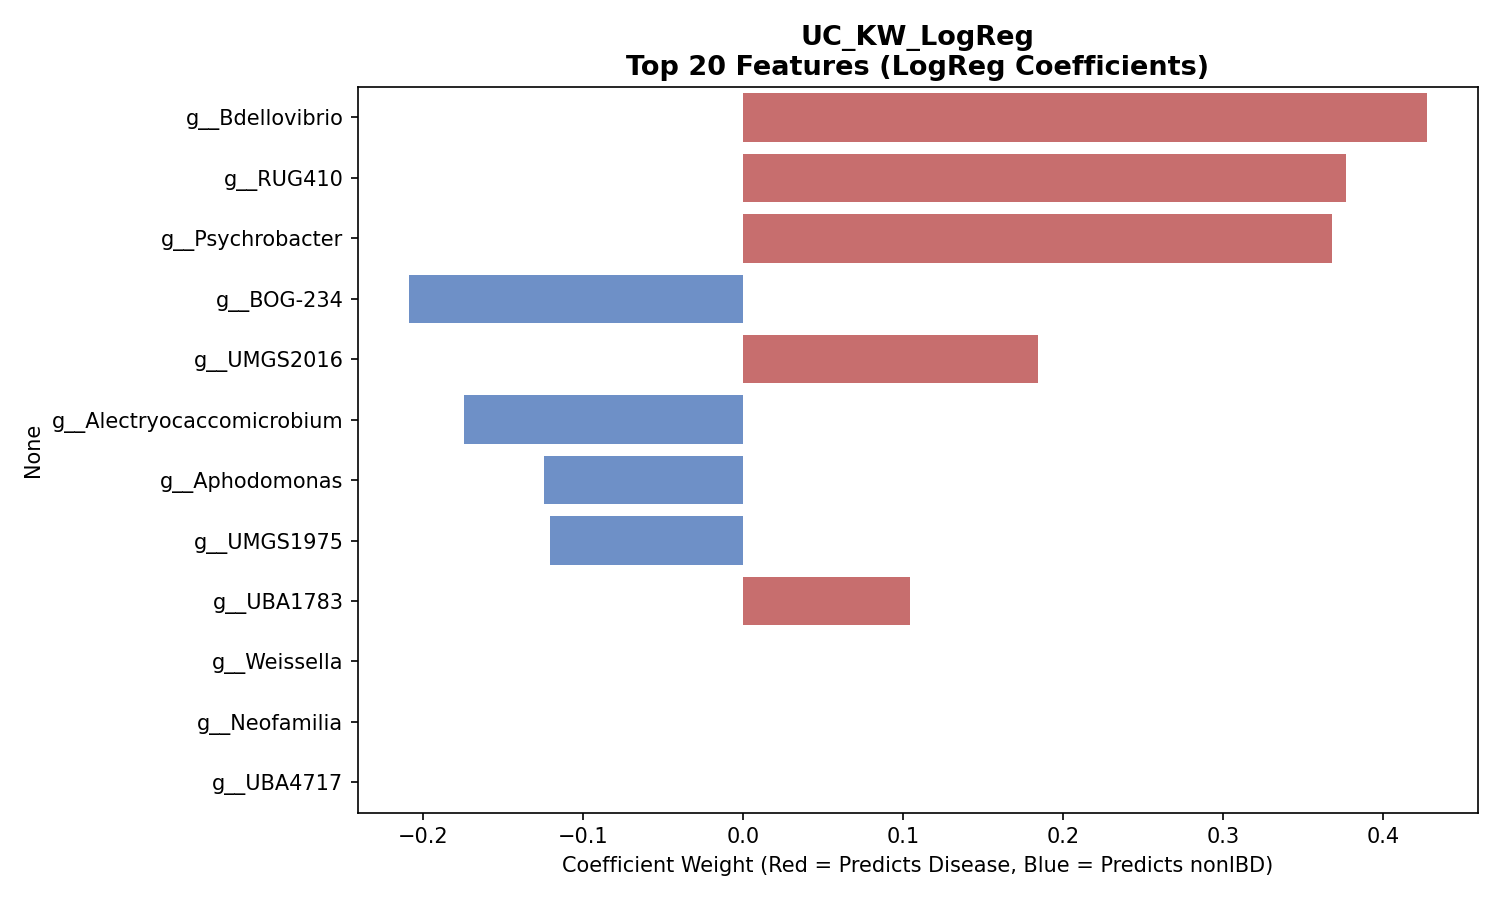

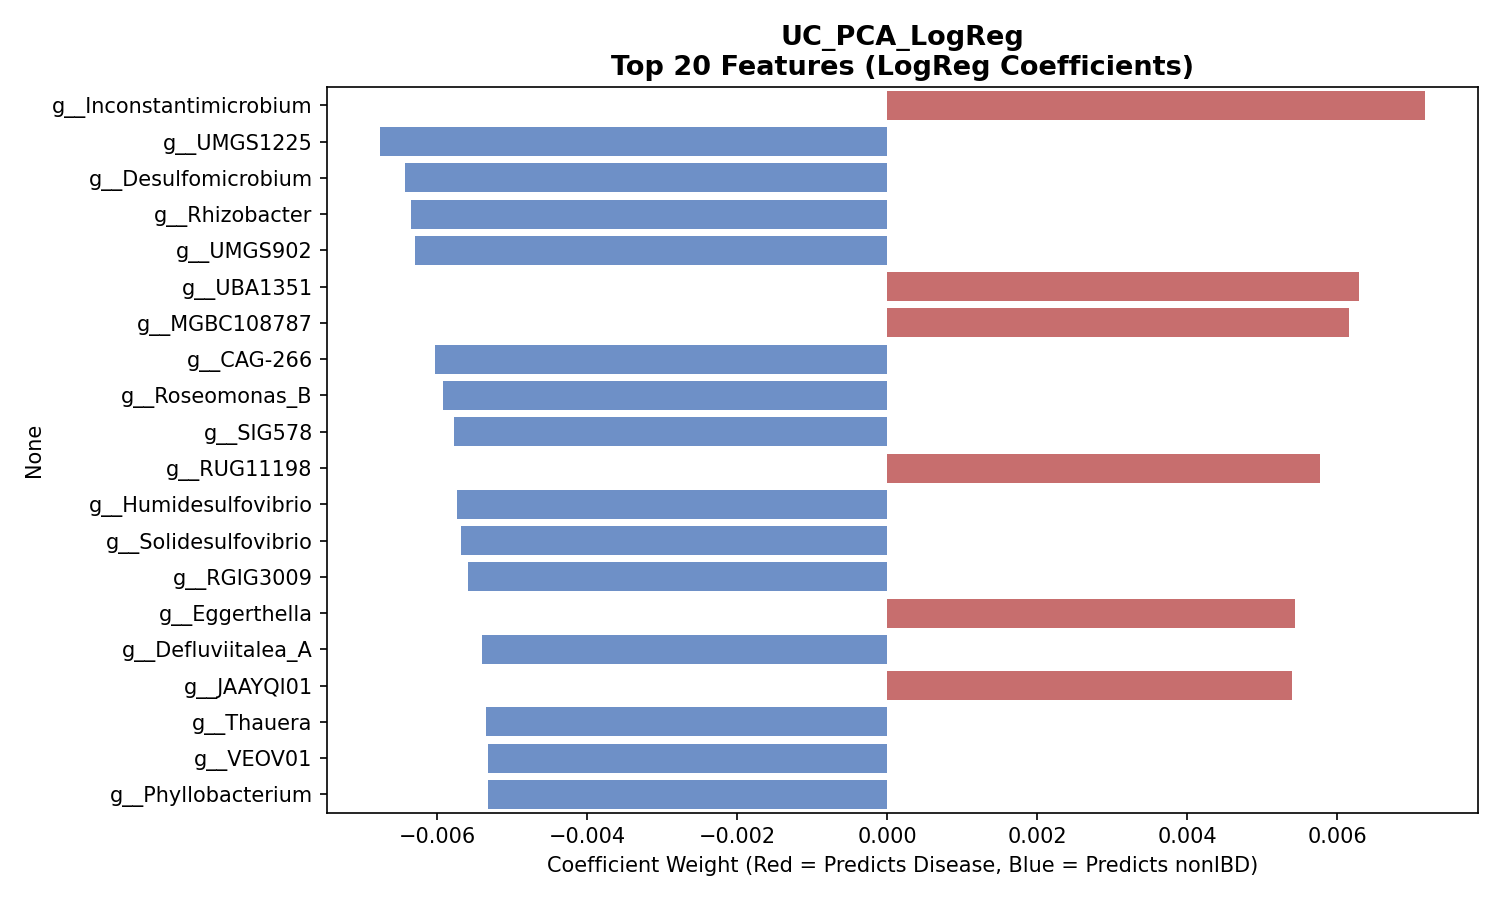



=== CD vs nonIBD: Logistic Regression Biomarkers ===


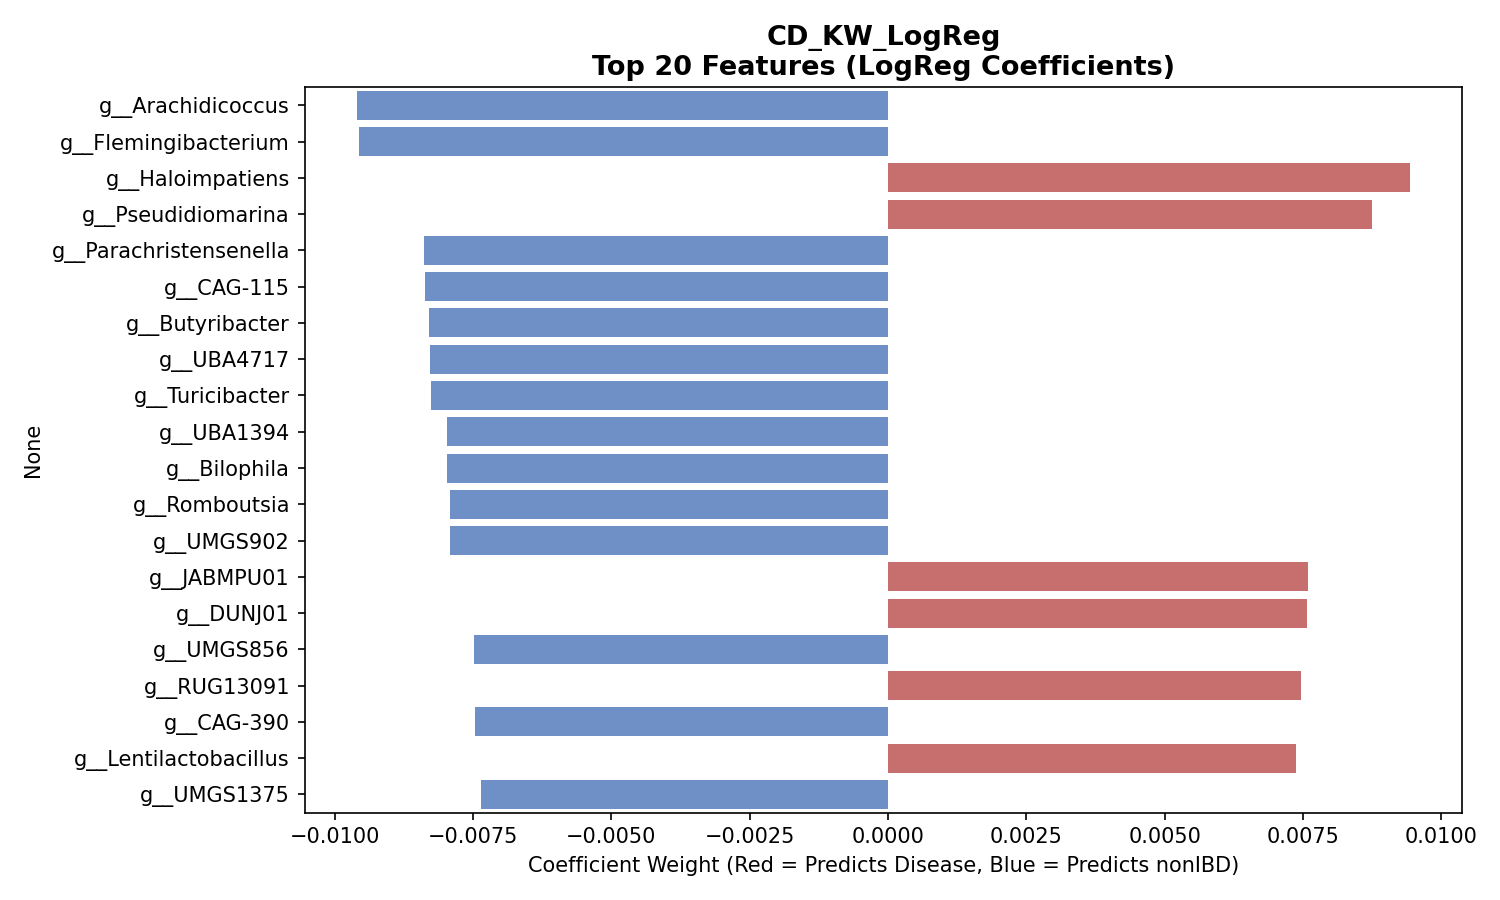

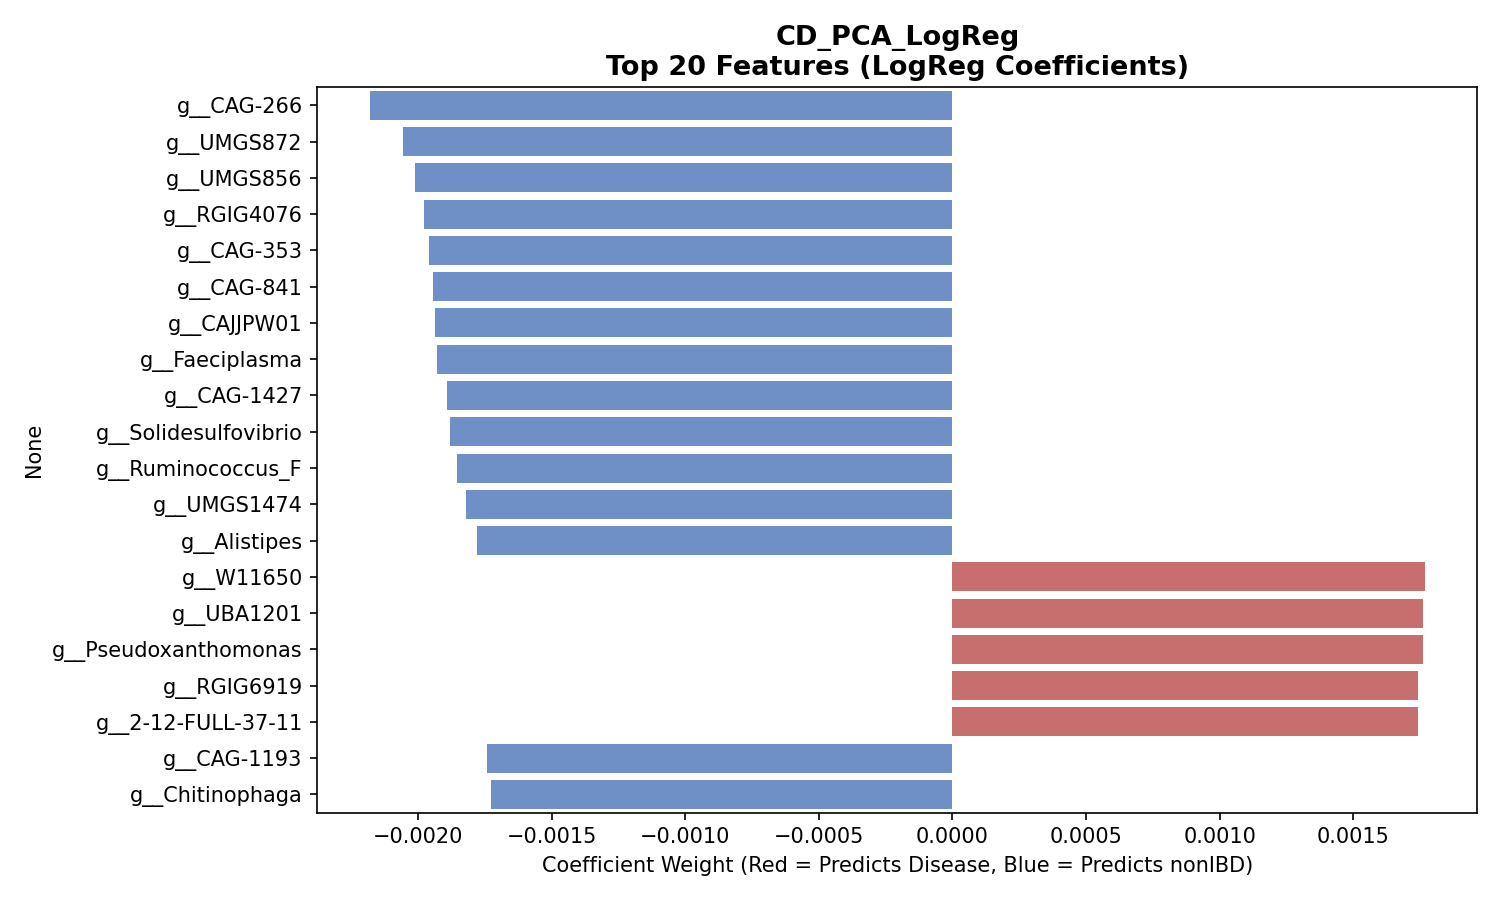

In [20]:
from IPython.display import Image, display

print("=== UC vs nonIBD: Logistic Regression Biomarkers ===")
# Display the Kruskal-Wallis model coefficients
display(Image(filename="../results/figures/xai_coef_uc_kw_logreg.png"))
# Display the PCA (Inverse-transformed) model coefficients
display(Image(filename="../results/figures/xai_coef_uc_pca_logreg.png"))

print("\n" + "="*50 + "\n")

print("=== CD vs nonIBD: Logistic Regression Biomarkers ===")
# Display the Kruskal-Wallis model coefficients
display(Image(filename="../results/figures/xai_coef_cd_kw_logreg.png"))
# Display the PCA (Inverse-transformed) model coefficients
display(Image(filename="../results/figures/xai_coef_cd_pca_logreg.png"))

### 4. Support Vector Machine Explainability (SHAP)
SVMs with non-linear kernels (`rbf`, `poly`, `sigmoid`) warp the feature space, making direct coefficient extraction impossible. 

We apply `shap.KernelExplainer` to calculate the marginal contribution of each feature. For PCA-SVM pipelines, we calculate SHAP values for the Principal Components and project them backward to the 2,761 raw microbes.

In [21]:
# 4. Extracting and Plotting SVM SHAP Values

def extract_svm_shap(pipeline, X_raw, selector_type):
    """Calculates SHAP values for SVMs, handling the Inverse-PCA trick."""
    clf = pipeline.named_steps['clf']
    scaler = pipeline.named_steps['scaler']
    
    if selector_type == "KW":
        feat_sel = pipeline.named_steps['feat_sel']
        features = feat_sel.get_feature_names_out()
        X_sel = X_raw[features]
        X_sel_df = pd.DataFrame(X_sel, columns=features)
        
        # Mini-pipeline mapping scaled features to SVM probabilities
        predict_fn = lambda x: clf.predict_proba(scaler.transform(x))[:, 1]
        
        background = shap.kmeans(X_sel_df, 10)
        explainer = shap.KernelExplainer(predict_fn, background)
        shap_values = explainer.shap_values(X_sel_df, nsamples=100)
        
        return shap_values, X_sel_df
        
    elif selector_type == "PCA":
        pca = pipeline.named_steps['feat_sel']
        
        # Manually push data through Scaler and PCA
        X_scaled = scaler.transform(X_raw)
        X_pca = pca.transform(X_scaled)
        X_pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
        
        # Explainer looks directly at the PCA components
        predict_fn = lambda x: clf.predict_proba(x)[:, 1]
        
        background = shap.kmeans(X_pca_df, 10)
        explainer = shap.KernelExplainer(predict_fn, background)
        shap_values_pca = explainer.shap_values(X_pca_df, nsamples=100)
        
        # Inverse PCA Trick for SHAP
        shap_values_raw = np.dot(shap_values_pca, pca.components_)
        
        # Create a display dataframe with clean names
        X_raw_clean = X_raw.copy()
        X_raw_clean.columns = [g.split(";")[-1].strip() for g in X_raw.columns]
        
        return shap_values_raw, X_raw_clean

def plot_shap_summary(shap_vals, X_display, title, file_name):
    """Generates and saves a SHAP summary Bar plot."""
    plt.figure(figsize=(9, 7))
    shap.summary_plot(
        shap_vals, X_display, 
        plot_type="bar", max_display=20, show=False
    )
    plt.title(f"{title}\nTop 20 Features (Mean Absolute SHAP)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"../results/figures/{file_name}", dpi=150)
    plt.close()
    print(f"Saved: {file_name}")

print("\n=== Support Vector Machine Interpretability (SHAP) ===")
print("Note: KernelExplainer is computationally intensive. Progress bars will appear below.")

svm_models = {
    "UC_KW_SVM": (X_uc, "KW"),
    "UC_PCA_SVM": (X_uc, "PCA"),
    "CD_KW_SVM": (X_cd, "KW"),
    "CD_PCA_SVM": (X_cd, "PCA")
}

for model_name, (X_target, sel_type) in svm_models.items():
    try:
        print(f"\nProcessing {model_name}...")
        pipe = joblib.load(f"../results/final_{model_name.lower()}.pkl")
        
        shap_vals, X_disp = extract_svm_shap(pipe, X_target, sel_type)
        
        # Clean columns if they aren't already cleaned (for KW)
        if sel_type == "KW":
            X_disp.columns = [g.split(";")[-1].strip() for g in X_disp.columns]
            
        plot_shap_summary(shap_vals, X_disp, model_name, f"xai_shap_bar_{model_name.lower()}.png")
        
    except FileNotFoundError:
        print(f"Skipping {model_name}: File not found.")


=== Support Vector Machine Interpretability (SHAP) ===
Note: KernelExplainer is computationally intensive. Progress bars will appear below.

Processing UC_KW_SVM...


  0%|          | 0/56 [00:00<?, ?it/s]

Saved: xai_shap_bar_uc_kw_svm.png

Processing UC_PCA_SVM...


  0%|          | 0/56 [00:00<?, ?it/s]

Saved: xai_shap_bar_uc_pca_svm.png

Processing CD_KW_SVM...


  0%|          | 0/75 [00:00<?, ?it/s]

Saved: xai_shap_bar_cd_kw_svm.png

Processing CD_PCA_SVM...


  0%|          | 0/75 [00:00<?, ?it/s]

Saved: xai_shap_bar_cd_pca_svm.png


=== UC vs nonIBD: Support Vector Machine Biomarkers (SHAP) ===


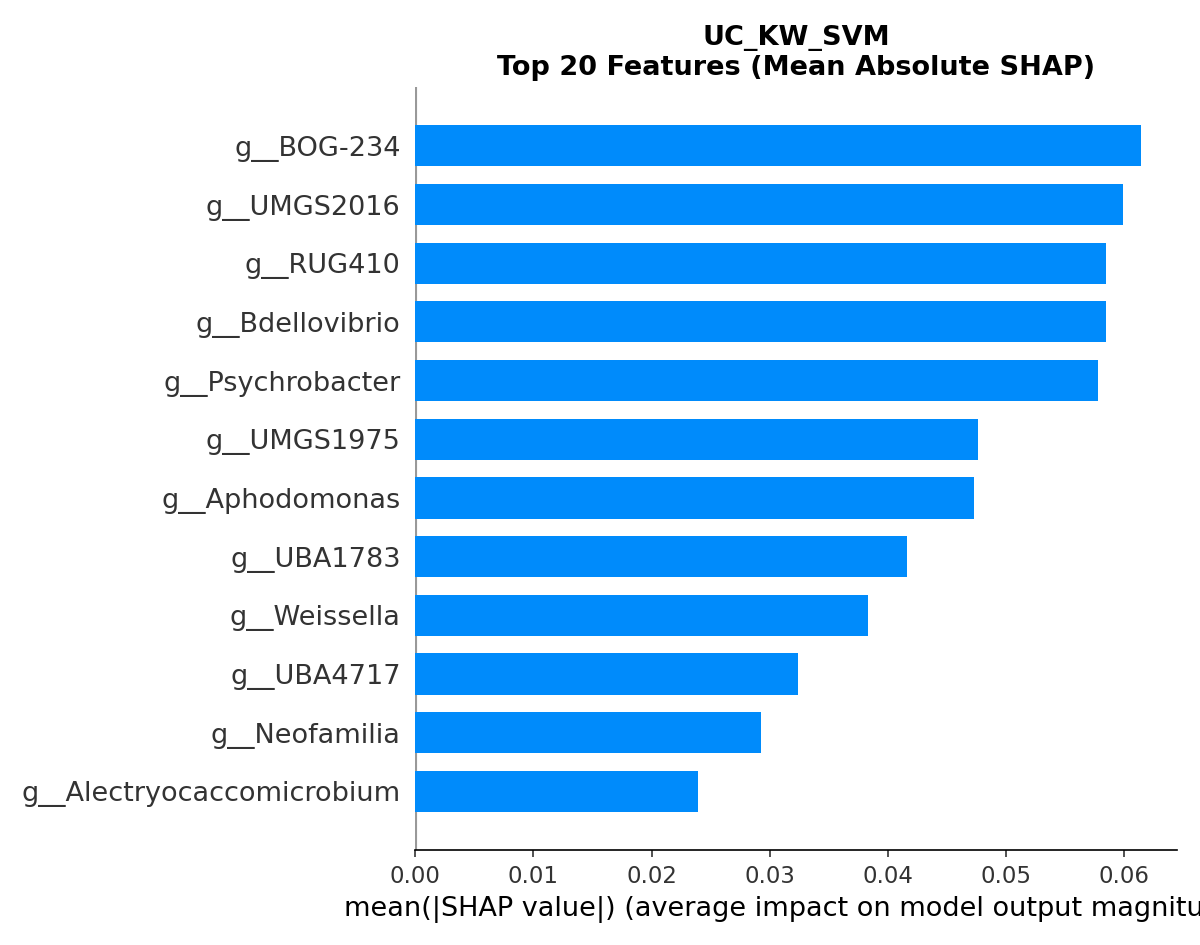

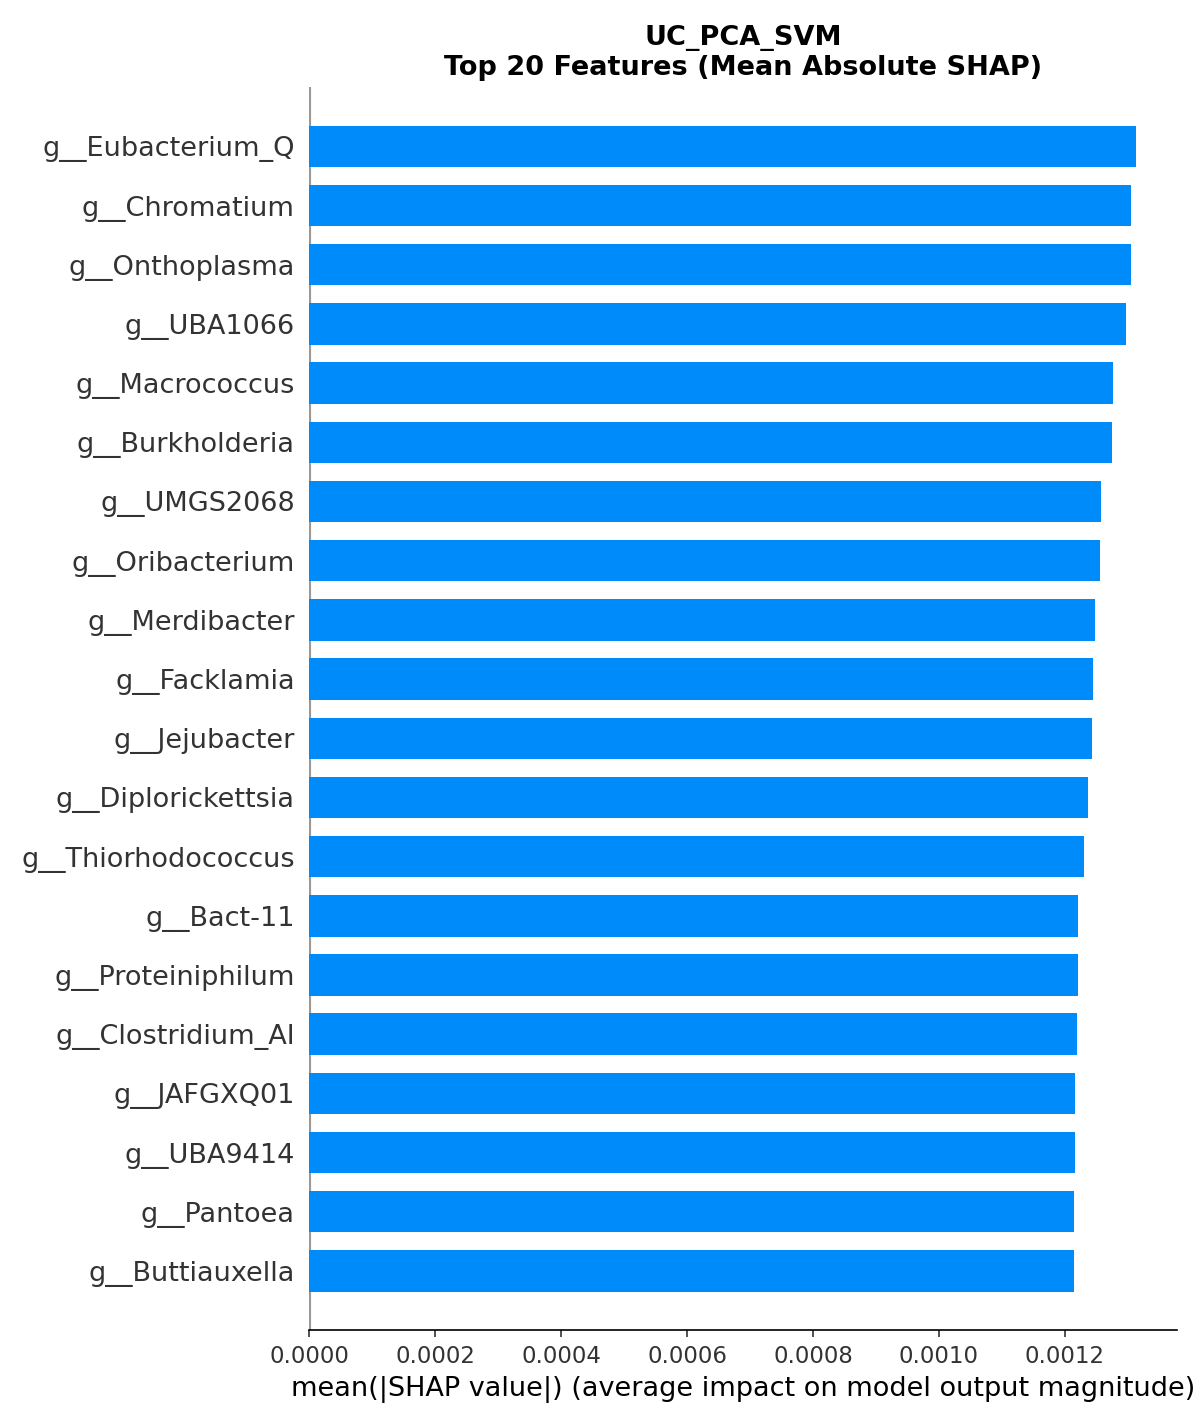



=== CD vs nonIBD: Support Vector Machine Biomarkers (SHAP) ===


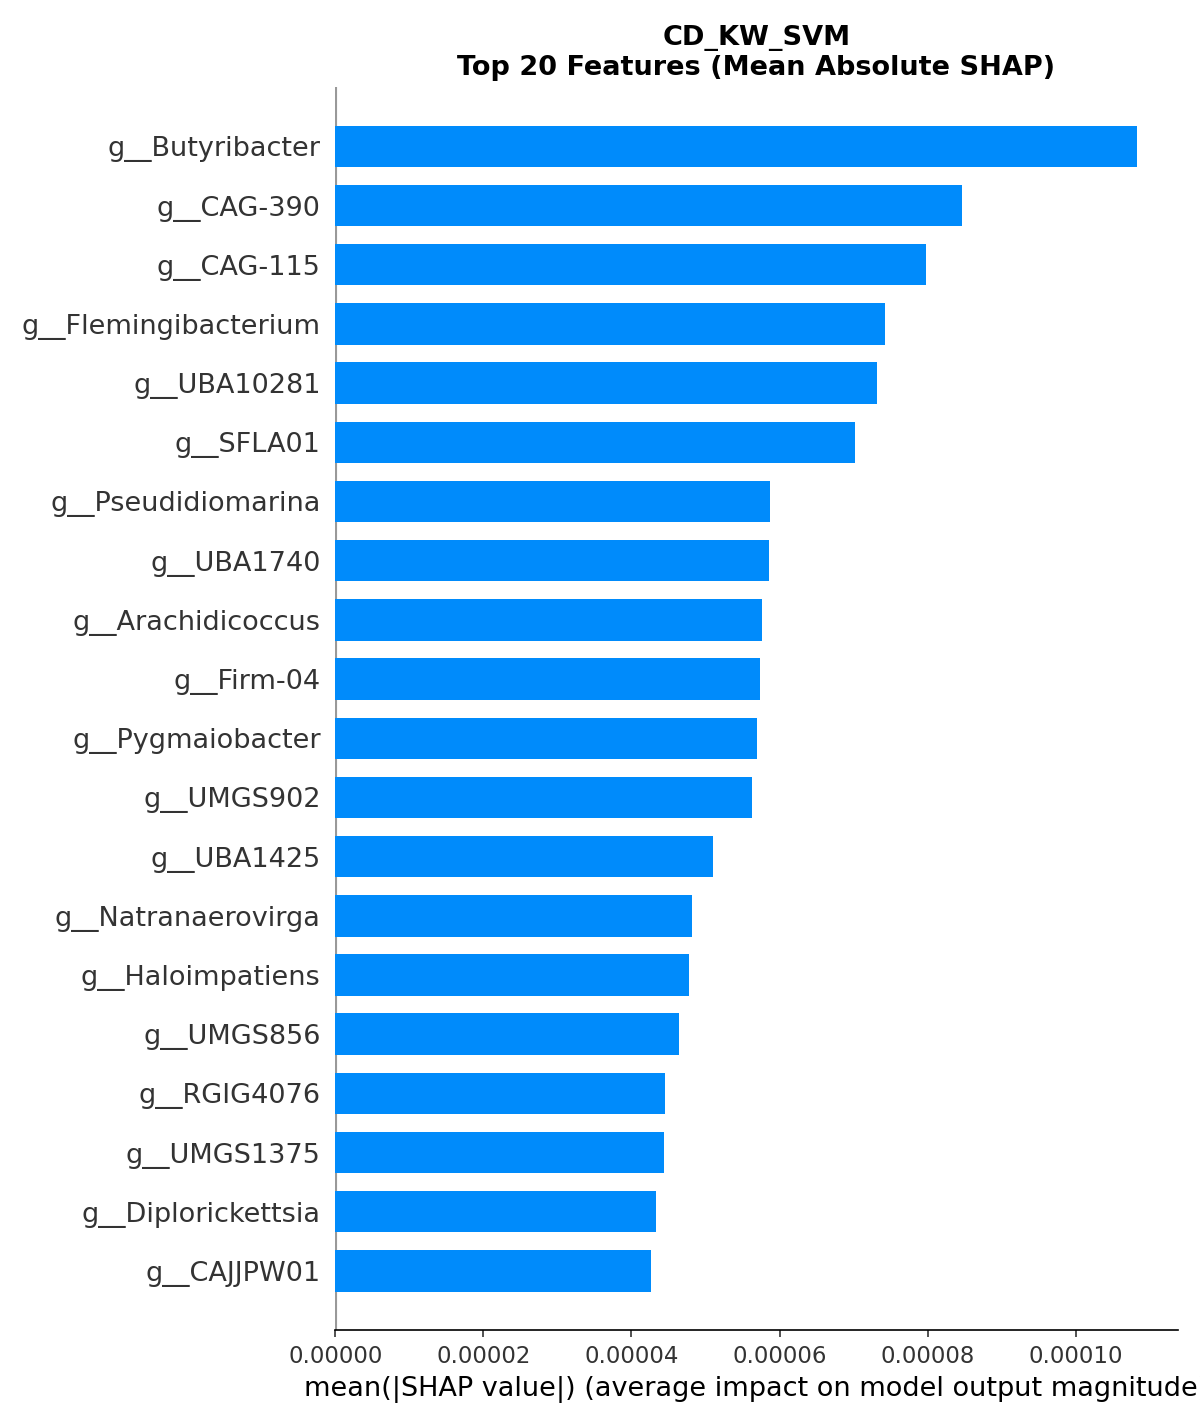

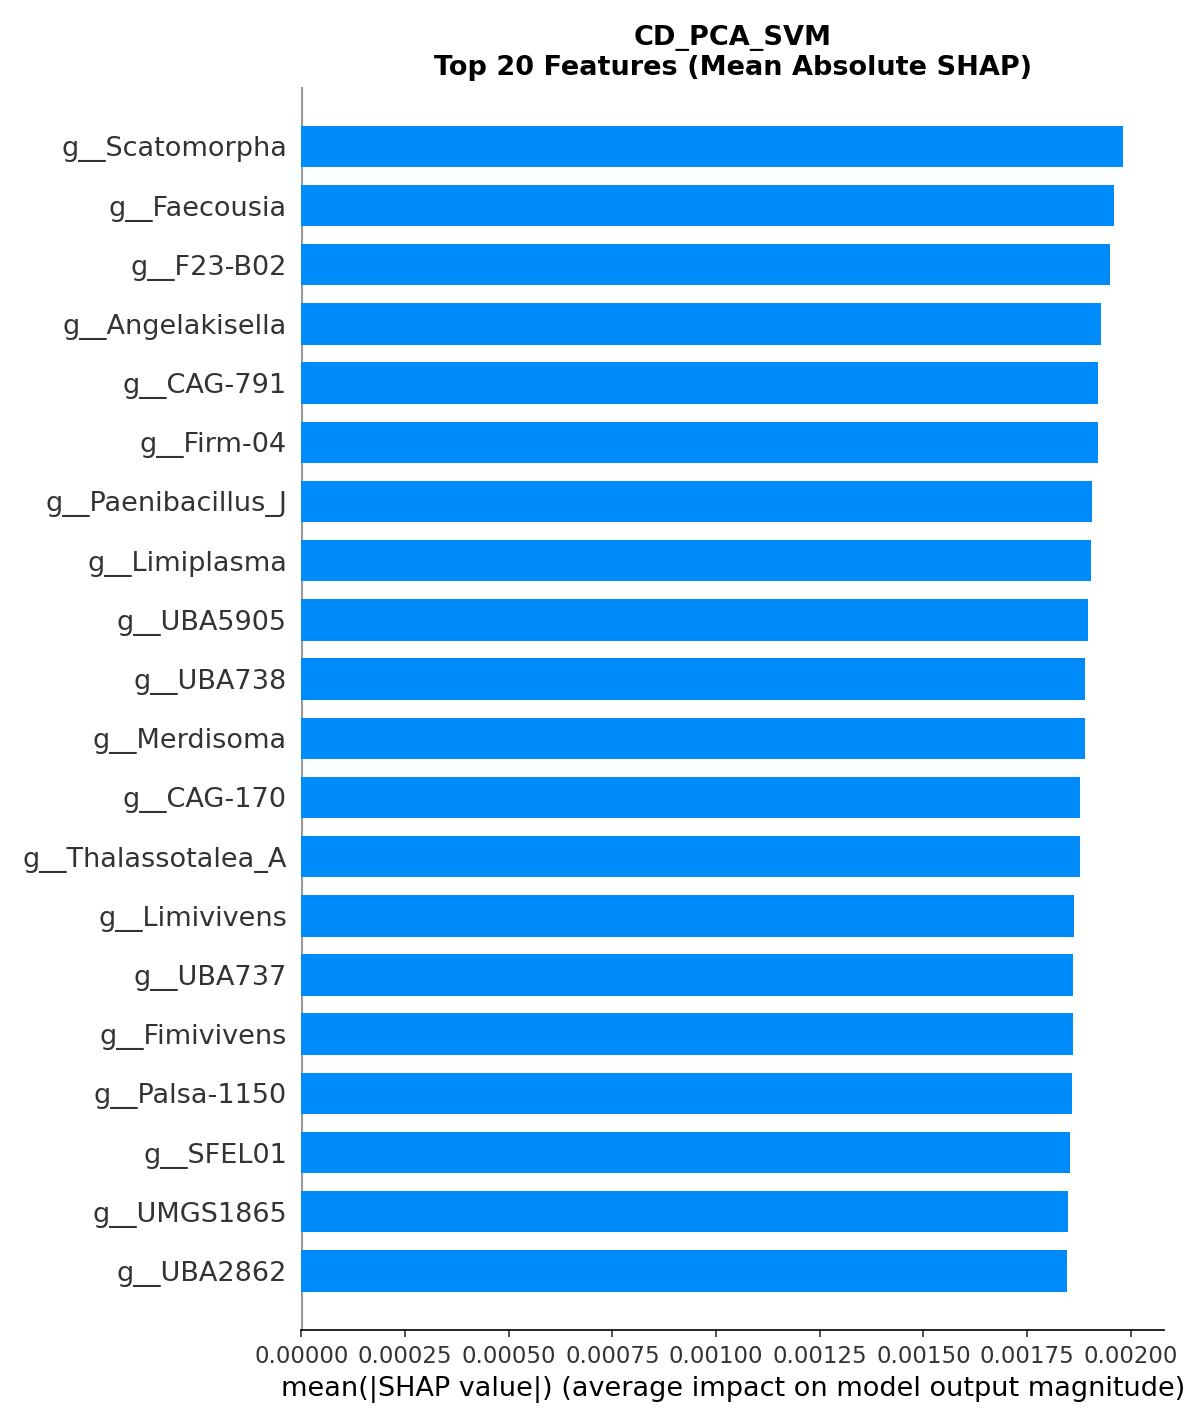

In [22]:
from IPython.display import Image, display

print("=== UC vs nonIBD: Support Vector Machine Biomarkers (SHAP) ===")
# Display the Kruskal-Wallis model SHAP values
display(Image(filename="../results/figures/xai_shap_bar_uc_kw_svm.png"))
# Display the PCA (Inverse-transformed) model SHAP values
display(Image(filename="../results/figures/xai_shap_bar_uc_pca_svm.png"))

print("\n" + "="*50 + "\n")

print("=== CD vs nonIBD: Support Vector Machine Biomarkers (SHAP) ===")
# Display the Kruskal-Wallis model SHAP values
display(Image(filename="../results/figures/xai_shap_bar_cd_kw_svm.png"))
# Display the PCA (Inverse-transformed) model SHAP values
display(Image(filename="../results/figures/xai_shap_bar_cd_pca_svm.png"))

### 5. Final Conclusion
By applying inverse-transformations to both linear coefficients and non-linear SHAP values, we have successfully mapped the abstract mathematical logic of all 8 models back to the original 2,761 microbial ecosystem. 

These figures (`xai_coef_*.png` and `xai_shap_bar_*.png`) isolate the most potent diagnostic biomarkers, providing clear, interpretable targets for subsequent biological literature review.

### 5. Automated Consensus Biomarker & Specificity Analysis

To move from Machine Learning to Biological Discovery, we must synthesize the outputs of all 8 models. 

**Analytical Strategy:**
1. **Consensus Scoring:** We extract the Top 20 features from all 4 models per disease. A bacterium receives a "vote" for each model it appears in. High-vote microbes (e.g., 3 or 4 votes) are our **Tier 1 Consensus Biomarkers**, representing rock-solid biological signals resistant to algorithm bias.
2. **Directional Mapping:** We map the linear direction from the Logistic Regression models to these consensus features to label them as either **Pathogenic (+)** or **Protective (-)**.
3. **Disease Specificity:** We intersect the master list of UC biomarkers with the CD biomarkers to test if the two Inflammatory Bowel Diseases share a common microbial signature, or if their microbiomes are entirely distinct.

In [23]:
import pandas as pd
import numpy as np

print("=== Extracting Master Top 20 Lists ===")
# Dictionaries to hold our Top 20 lists and LogReg directions
master_lists = {'UC': {}, 'CD': {}}
logreg_directions = {'UC': {}, 'CD': {}}

def get_top_20(series, is_logreg=False):
    """Cleans names and extracts the Top 20 features and their directions."""
    clean_series = series.copy()
    clean_series.index = [g.split(";")[-1].strip() for g in clean_series.index]
    top_20 = clean_series.abs().sort_values(ascending=False).head(20)
    
    dirs = {}
    if is_logreg:
        for feat in top_20.index:
            # Positive = Red = Pathogenic | Negative = Blue = Protective
            dirs[feat] = "Pathogen (+)" if clean_series[feat] > 0 else "Protective (-)"
    return top_20.index.tolist(), dirs

# 1. Re-extract features systematically (This will run very fast)
for task in ['UC', 'CD']:
    X_target = X_uc if task == 'UC' else X_cd
    
    # LogReg Extraction
    for sel in ['KW', 'PCA']:
        pipe = joblib.load(f"../results/final_{task.lower()}_{sel.lower()}_logreg.pkl")
        coefs = extract_logreg_coefs(pipe, X_target, sel)
        top_list, dirs = get_top_20(coefs, is_logreg=True)
        
        master_lists[task][f"{sel}_LogReg"] = top_list
        logreg_directions[task].update(dirs) # Combine KW and PCA directions
        
    # SVM Extraction
    for sel in ['KW', 'PCA']:
        pipe = joblib.load(f"../results/final_{task.lower()}_{sel.lower()}_svm.pkl")
        shap_vals, X_disp = extract_svm_shap(pipe, X_target, sel)
        
        if sel == "KW":
            X_disp.columns = [g.split(";")[-1].strip() for g in X_disp.columns]
            
        mean_shap = np.abs(shap_vals).mean(axis=0)
        shap_series = pd.Series(mean_shap, index=X_disp.columns)
        top_list, _ = get_top_20(shap_series, is_logreg=False)
        
        master_lists[task][f"{sel}_SVM"] = top_list

# 2. Build Consensus DataFrames
def build_consensus_table(task):
    all_features = set()
    for lst in master_lists[task].values():
        all_features.update(lst)
        
    rows = []
    for feat in all_features:
        row = {'Microbe': feat}
        votes = 0
        for model_name, top_list in master_lists[task].items():
            is_in_model = feat in top_list
            row[model_name] = "✔️" if is_in_model else ""
            if is_in_model: votes += 1
            
        row['Total_Votes'] = votes
        row['LogReg_Direction'] = logreg_directions[task].get(feat, "Neutral/Non-Linear")
        rows.append(row)
        
    df = pd.DataFrame(rows).sort_values(by=['Total_Votes', 'Microbe'], ascending=[False, True])
    # Filter to show only "Consensus" (At least 2 votes)
    return df[df['Total_Votes'] >= 2].reset_index(drop=True)

df_uc_consensus = build_consensus_table('UC')
df_cd_consensus = build_consensus_table('CD')

print("\n" + "="*60)
print("🏆 TIER 1 CONSENSUS BIOMARKERS: UC vs nonIBD")
print("="*60)
display(df_uc_consensus)

print("\n" + "="*60)
print("🏆 TIER 1 CONSENSUS BIOMARKERS: CD vs nonIBD")
print("="*60)
display(df_cd_consensus)

# 3. Disease Specificity Check (Overlap)
print("\n" + "="*60)
print("🔍 DISEASE SPECIFICITY CHECK (UC vs CD Overlap)")
print("="*60)

uc_all_features = set()
for lst in master_lists['UC'].values(): uc_all_features.update(lst)
    
cd_all_features = set()
for lst in master_lists['CD'].values(): cd_all_features.update(lst)

overlap = uc_all_features.intersection(cd_all_features)

print(f"Total Unique UC Biomarkers (across all top 20s): {len(uc_all_features)}")
print(f"Total Unique CD Biomarkers (across all top 20s): {len(cd_all_features)}")
print(f"Number of Microbes shared between UC and CD: {len(overlap)}")

if len(overlap) > 0:
    print(f"\nShared Microbes:")
    for bug in overlap:
        uc_dir = logreg_directions['UC'].get(bug, "Non-Linear")
        cd_dir = logreg_directions['CD'].get(bug, "Non-Linear")
        print(f" - {bug} | UC Behavior: {uc_dir} | CD Behavior: {cd_dir}")
else:
    print("\nConclusion: 0% overlap. UC and CD display entirely distinct microbial signatures in this cohort.")

=== Extracting Master Top 20 Lists ===


  0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


🏆 TIER 1 CONSENSUS BIOMARKERS: UC vs nonIBD


,Microbe,KW_LogReg,PCA_LogReg,KW_SVM,PCA_SVM,Total_Votes,LogReg_Direction
0,g__Alectryocaccomicrobium,✔️,,✔️,,2,Protective (-)
1,g__Aphodomonas,✔️,,✔️,,2,Protective (-)
2,g__BOG-234,✔️,,✔️,,2,Protective (-)
3,g__Bdellovibrio,✔️,,✔️,,2,Pathogen (+)
4,g__Neofamilia,✔️,,✔️,,2,Protective (-)
5,g__Psychrobacter,✔️,,✔️,,2,Pathogen (+)
6,g__RUG410,✔️,,✔️,,2,Pathogen (+)
7,g__UBA1783,✔️,,✔️,,2,Pathogen (+)
8,g__UBA4717,✔️,,✔️,,2,Protective (-)
9,g__UMGS1975,✔️,,✔️,,2,Protective (-)



🏆 TIER 1 CONSENSUS BIOMARKERS: CD vs nonIBD


,Microbe,KW_LogReg,PCA_LogReg,KW_SVM,PCA_SVM,Total_Votes,LogReg_Direction
0,g__UMGS856,✔️,✔️,✔️,,3,Protective (-)
1,g__Butyribacter,✔️,,✔️,,2,Protective (-)
2,g__CAG-115,✔️,,✔️,,2,Protective (-)
3,g__CAG-353,,✔️,✔️,,2,Protective (-)
4,g__CAG-390,✔️,,✔️,,2,Protective (-)
5,g__Firm-04,,,✔️,✔️,2,Neutral/Non-Linear
6,g__Flemingibacterium,✔️,,✔️,,2,Protective (-)
7,g__Haloimpatiens,✔️,,✔️,,2,Pathogen (+)
8,g__UBA4717,✔️,,✔️,,2,Protective (-)
9,g__UBA5905,,,✔️,✔️,2,Neutral/Non-Linear



🔍 DISEASE SPECIFICITY CHECK (UC vs CD Overlap)
Total Unique UC Biomarkers (across all top 20s): 52
Total Unique CD Biomarkers (across all top 20s): 68
Number of Microbes shared between UC and CD: 4

Shared Microbes:
 - g__Solidesulfovibrio | UC Behavior: Protective (-) | CD Behavior: Protective (-)
 - g__UBA4717 | UC Behavior: Protective (-) | CD Behavior: Protective (-)
 - g__CAG-266 | UC Behavior: Protective (-) | CD Behavior: Protective (-)
 - g__UMGS902 | UC Behavior: Protective (-) | CD Behavior: Protective (-)


In [24]:
import os

# Create the folder if it doesn't exist
os.makedirs('../results/tables', exist_ok=True)

# Save the two master consensus tables we generated earlier in Notebook 6
df_uc_consensus.to_csv("../results/tables/uc_master_consensus.csv", index=False)
df_cd_consensus.to_csv("../results/tables/cd_master_consensus.csv", index=False)

print("✅ Saved 'uc_master_consensus.csv'")
print("✅ Saved 'cd_master_consensus.csv'")

✅ Saved 'uc_master_consensus.csv'
✅ Saved 'cd_master_consensus.csv'
